Zadanie 12 – t-SNE na embeddingach BERT

Pobierz embeddingi `[CLS]` z DistilBERT dla 500 tekstów z 20 Newsgroups (4 kategorie). Zwizualizuj za pomocą t-SNE i UMAP. Czy kategorie są wyraźnie oddzielone?

Oczekiwany wynik: wizualizacja z kolorami kategorii


Import bibliotek...
Import OK
Ładowanie 20 Newsgroups...
Tekstów: 500
Kategorie: ['baseball', 'space', 'graphics', 'misc']
Rozkład klas: [128 142 127 103]
Ładowanie DistilBERT (lokalny cache)...
Urządzenie: mps

Ekstrakcja embeddingów [CLS]...
  embeddingi: batch 1/32 (16/500)
  embeddingi: batch 5/32 (80/500)
  embeddingi: batch 10/32 (160/500)
  embeddingi: batch 15/32 (240/500)
  embeddingi: batch 20/32 (320/500)
  embeddingi: batch 25/32 (400/500)
  embeddingi: batch 30/32 (480/500)
  embeddingi: batch 32/32 (500/500)
Embeddingi: (500, 768) (czas: 2.6s)

Obliczanie t-SNE...
t-SNE: 0.9s | KL divergence: 0.8479
Obliczanie UMAP...
UMAP: 2.8s


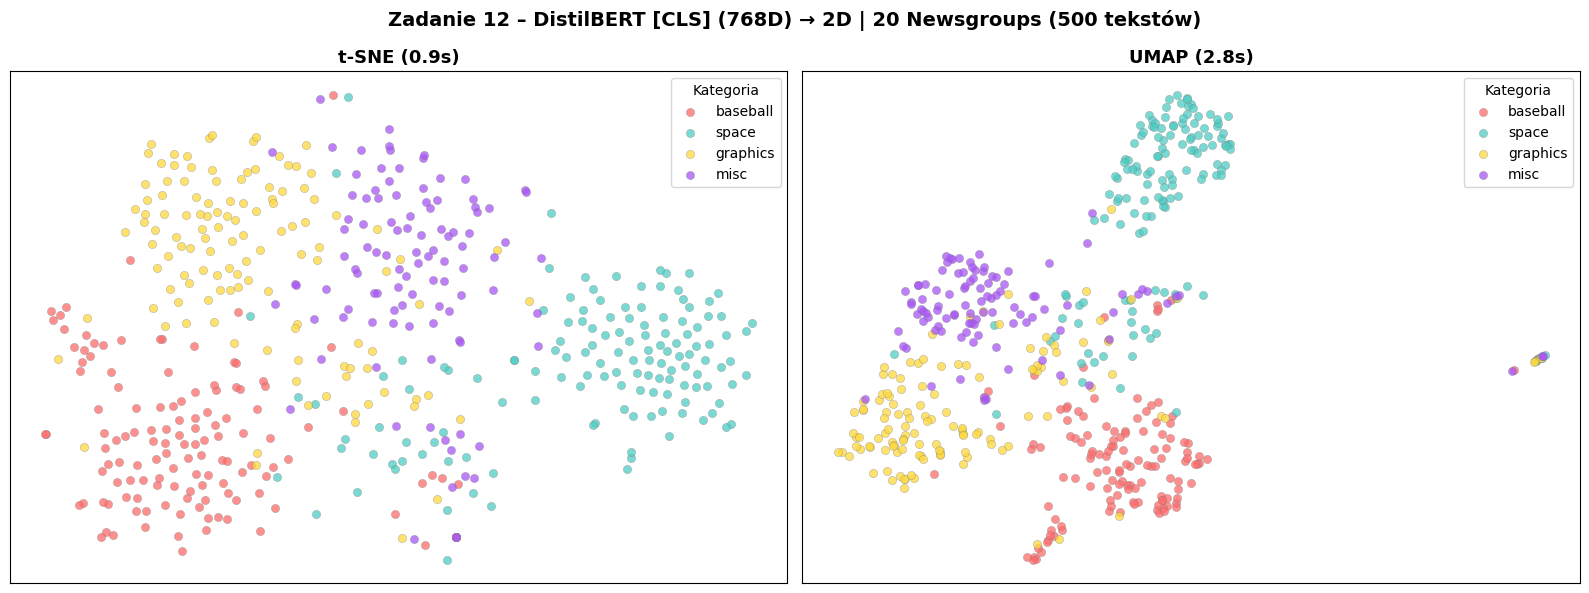


=== Separacja (średnia odległość wewnątrz / między klasami) ===
t-SNE: intra=17.09, inter=34.74, stosunek inter/intra=2.03
UMAP:  intra=1.92, inter=3.98, stosunek inter/intra=2.07
(im wyższy stosunek inter/intra, tym wyraźniejsza separacja klas)


In [ ]:
# Zadanie 12 – DistilBERT [CLS] + t-SNE / UMAP (20 Newsgroups)
# Wzorowane na: Przykład 6 (t-SNE vs UMAP) i Przykład 8 (embeddingi + t-SNE) z lekcja37teoria
import os
import sys
import warnings

warnings.filterwarnings("ignore")
os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba_cache")
os.environ.setdefault("HF_HOME", os.path.join(os.getcwd(), ".hf_cache"))
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# UMAP przy starcie próbuje załadować TensorFlow (ParametricUMAP) — u nas TF wisi.
# Blokada powoduje czysty ImportError i UMAP działa bez TF.
sys.modules["tensorflow"] = None
sys.modules["keras"] = None

print("Import bibliotek...", flush=True)
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import fetch_20newsgroups
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from transformers import AutoTokenizer, AutoModel
import umap

print("Import OK", flush=True)

# === Dane: 4 kategorie + 500 tekstów ===
categories = [
    "rec.sport.baseball",
    "sci.space",
    "comp.graphics",
    "talk.politics.misc",
]
short_names = [c.split(".")[-1] for c in categories]
cat_colors = ["#ff6b6b", "#4ecdc4", "#ffd93d", "#a855f7"]

print("Ładowanie 20 Newsgroups...", flush=True)
data = fetch_20newsgroups(
    subset="train",
    categories=categories,
    remove=("headers", "footers", "quotes"),
    random_state=42,
)

rng = np.random.default_rng(42)
n_samples = 500
idx = rng.choice(len(data.data), size=n_samples, replace=False)
texts = [data.data[i] for i in idx]
labels = data.target[idx]

print(f"Tekstów: {len(texts)}", flush=True)
print(f"Kategorie: {short_names}", flush=True)
print(f"Rozkład klas: {np.bincount(labels)}", flush=True)

# === DistilBERT: embeddingi tokenu [CLS] ===
model_name = "distilbert-base-uncased"
print("Ładowanie DistilBERT (lokalny cache)...", flush=True)
tokenizer = AutoTokenizer.from_pretrained(model_name, local_files_only=True)
model = AutoModel.from_pretrained(model_name, local_files_only=True)
model.eval()

if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model.to(device)
print(f"Urządzenie: {device}", flush=True)


def extract_cls_embeddings(texts, batch_size=16, max_length=128):
    """Zwraca macierz embeddingów [CLS] o kształcie (n, hidden_dim)."""
    all_cls = []
    n_batches = (len(texts) + batch_size - 1) // batch_size
    with torch.no_grad():
        for b_i, start in enumerate(range(0, len(texts), batch_size), start=1):
            batch = texts[start:start + batch_size]
            encoded = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt",
            )
            encoded = {k: v.to(device) for k, v in encoded.items()}
            outputs = model(**encoded)
            cls = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_cls.append(cls)
            if b_i == 1 or b_i % 5 == 0 or b_i == n_batches:
                print(f"  embeddingi: batch {b_i}/{n_batches} ({min(start + batch_size, len(texts))}/{len(texts)})", flush=True)
    return np.vstack(all_cls)


print("\nEkstrakcja embeddingów [CLS]...", flush=True)
t0 = time.perf_counter()
X_emb = extract_cls_embeddings(texts)
emb_time = time.perf_counter() - t0
print(f"Embeddingi: {X_emb.shape} (czas: {emb_time:.1f}s)", flush=True)

X_std = StandardScaler().fit_transform(X_emb)

print("\nObliczanie t-SNE...", flush=True)
t0 = time.perf_counter()
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    max_iter=1000,
    random_state=42,
    init="pca",
)
X_tsne = tsne.fit_transform(X_std)
tsne_time = time.perf_counter() - t0
print(f"t-SNE: {tsne_time:.1f}s | KL divergence: {tsne.kl_divergence_:.4f}", flush=True)

print("Obliczanie UMAP...", flush=True)
t0 = time.perf_counter()
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42,
)
X_umap = reducer.fit_transform(X_std)
umap_time = time.perf_counter() - t0
print(f"UMAP: {umap_time:.1f}s", flush=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, X_2d, title, elapsed in [
    (axes[0], X_tsne, "t-SNE", tsne_time),
    (axes[1], X_umap, "UMAP", umap_time),
]:
    for cat_idx, (name, color) in enumerate(zip(short_names, cat_colors)):
        mask = labels == cat_idx
        ax.scatter(
            X_2d[mask, 0],
            X_2d[mask, 1],
            c=color,
            label=name,
            alpha=0.75,
            s=35,
            edgecolors="gray",
            linewidth=0.3,
        )
    ax.set_title(f"{title} ({elapsed:.1f}s)", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10, title="Kategoria")
    ax.grid(True, alpha=0.3)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(
    "Zadanie 12 – DistilBERT [CLS] (768D) → 2D | 20 Newsgroups (500 tekstów)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()


def mean_intra_inter(X_2d, y):
    intra, inter = [], []
    for c in np.unique(y):
        pts = X_2d[y == c]
        if len(pts) > 1:
            d = np.linalg.norm(pts[:, None, :] - pts[None, :, :], axis=-1)
            intra.append(d[np.triu_indices_from(d, k=1)].mean())
        others = X_2d[y != c]
        if len(pts) and len(others):
            d = np.linalg.norm(pts[:, None, :] - others[None, :, :], axis=-1)
            inter.append(d.mean())
    return float(np.mean(intra)), float(np.mean(inter))

intra_t, inter_t = mean_intra_inter(X_tsne, labels)
intra_u, inter_u = mean_intra_inter(X_umap, labels)
print("\n=== Separacja (średnia odległość wewnątrz / między klasami) ===", flush=True)
print(f"t-SNE: intra={intra_t:.2f}, inter={inter_t:.2f}, stosunek inter/intra={inter_t/intra_t:.2f}", flush=True)
print(f"UMAP:  intra={intra_u:.2f}, inter={inter_u:.2f}, stosunek inter/intra={inter_u/intra_u:.2f}", flush=True)
print("(im wyższy stosunek inter/intra, tym wyraźniejsza separacja klas)", flush=True)
